# PHYS 2550 — Homework 1

This notebook the builds linear-regression models using only **NumPy**, **pandas**, and **matplotlib**. The loss, gradients, and parameter updates are implemented explicitly; no regression routine from scikit-learn, `numpy.polyfit`, PyTorch, or a similar library is used.

The notebook is organized to match the homework.

## Setup

In [159]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Figures params.
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

## Part (a) — Get the data in

### Convert the spreadsheet and read the CSV

I converted the XLSX file directly in Python: `pandas.read_excel()` loads the
spreadsheet, and `DataFrame.to_csv()` saves it as a CSV without an additional index
column.

In [163]:
xlsx_file = "Real estate valuation data set.xlsx"
csv_file = "Real estate valuation data set.csv"

# Convert XLSX to CSV.
spreadsheet = pd.read_excel(xlsx_file)
spreadsheet.to_csv(csv_file, index=False)

# Read the CSV.
data = pd.read_csv(csv_file)

print(f"Number of rows: {len(data)}")
data.head()

Number of rows: 414


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


### Column meanings, units, and ranges

The transaction date is encoded as a decimal year; for example, 2013.250 denotes
March 2013. A "ping" is a Taiwanese unit of area equal to approximately 3.3 square
metres. The `No` column is only a row identifier and will not be used as a predictor.

In [166]:
descriptions = {
    "No": "Row identifier",
    "X1 transaction date": "Date when the property transaction occurred",
    "X2 house age": "Age of the house",
    "X3 distance to the nearest MRT station":
        "Distance from the house to the nearest MRT station",
    "X4 number of convenience stores":
        "Number of convenience stores within walking distance",
    "X5 latitude": "Geographic latitude of the house",
    "X6 longitude": "Geographic longitude of the house",
    "Y house price of unit area": "House price per unit area",
}

units = {
    "No": "None",
    "X1 transaction date": "Decimal year",
    "X2 house age": "Years",
    "X3 distance to the nearest MRT station": "Metres",
    "X4 number of convenience stores": "Count",
    "X5 latitude": "Degrees",
    "X6 longitude": "Degrees",
    "Y house price of unit area": "10,000 New Taiwan dollars per ping",
}

column_summary = pd.DataFrame({
    "What it is": pd.Series(descriptions),
    "Units": pd.Series(units),
    "Minimum": data.min(),
    "Maximum": data.max(),
})
column_summary["Range"] = (
    column_summary["Minimum"].map(lambda value: f"{value:g}")
    + " to "
    + column_summary["Maximum"].map(lambda value: f"{value:g}")
)

column_summary

,What it is,Units,Minimum,Maximum,Range
No,Row identifier,None,1.000000,414.000000,1 to 414
X1 transaction date,Date when the property transaction occurred,Decimal year,2012.666667,2013.583333,2012.67 to 2013.58
X2 house age,Age of the house,Years,0.000000,43.800000,0 to 43.8
X3 distance to the nearest MRT station,Distance from the house to the nearest MRT sta...,Metres,23.382840,6488.021000,23.3828 to 6488.02
X4 number of convenience stores,Number of convenience stores within walking di...,Count,0.000000,10.000000,0 to 10
X5 latitude,Geographic latitude of the house,Degrees,24.932070,25.014590,24.9321 to 25.0146
X6 longitude,Geographic longitude of the house,Degrees,121.473530,121.566270,121.474 to 121.566
Y house price of unit area,House price per unit area,"10,000 New Taiwan dollars per ping",7.600000,117.500000,7.6 to 117.5


### Data-quality checks

The following checks use all 414 rows. We verify the data types, count missing values, and summarize the numerical
distributions.

In [169]:
data.info()

missing_values = data.isna().sum().rename("Missing values")
print("\nMissing values by column:")
display(missing_values.to_frame())

data.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 8 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   No                                      414 non-null    int64  
 1   X1 transaction date                     414 non-null    float64
 2   X2 house age                            414 non-null    float64
 3   X3 distance to the nearest MRT station  414 non-null    float64
 4   X4 number of convenience stores         414 non-null    int64  
 5   X5 latitude                             414 non-null    float64
 6   X6 longitude                            414 non-null    float64
 7   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(2)
memory usage: 26.0 KB

Missing values by column:


,Missing values
No,0
X1 transaction date,0
X2 house age,0
X3 distance to the nearest MRT station,0
X4 number of convenience stores,0
X5 latitude,0
X6 longitude,0
Y house price of unit area,0


,count,mean,std,min,25%,50%,75%,max
No,414.0,207.500000,119.655756,1.000000,104.250000,207.500000,310.750000,414.000000
X1 transaction date,414.0,2013.148953,0.281995,2012.666667,2012.916667,2013.166667,2013.416667,2013.583333
X2 house age,414.0,17.712560,11.392485,0.000000,9.025000,16.100000,28.150000,43.800000
X3 distance to the nearest MRT station,414.0,1083.885689,1262.109595,23.382840,289.324800,492.231300,1454.279000,6488.021000
X4 number of convenience stores,414.0,4.094203,2.945562,0.000000,1.000000,4.000000,6.000000,10.000000
X5 latitude,414.0,24.969030,0.012410,24.932070,24.963000,24.971100,24.977455,25.014590
X6 longitude,414.0,121.533361,0.015347,121.473530,121.528085,121.538630,121.543305,121.566270
Y house price of unit area,414.0,37.980193,13.606488,7.600000,27.700000,38.450000,46.600000,117.500000


### Histograms of the target and two required features

The target is price per unit area. House age is the feature used in part (b), and MRT
distance is added in part (c).

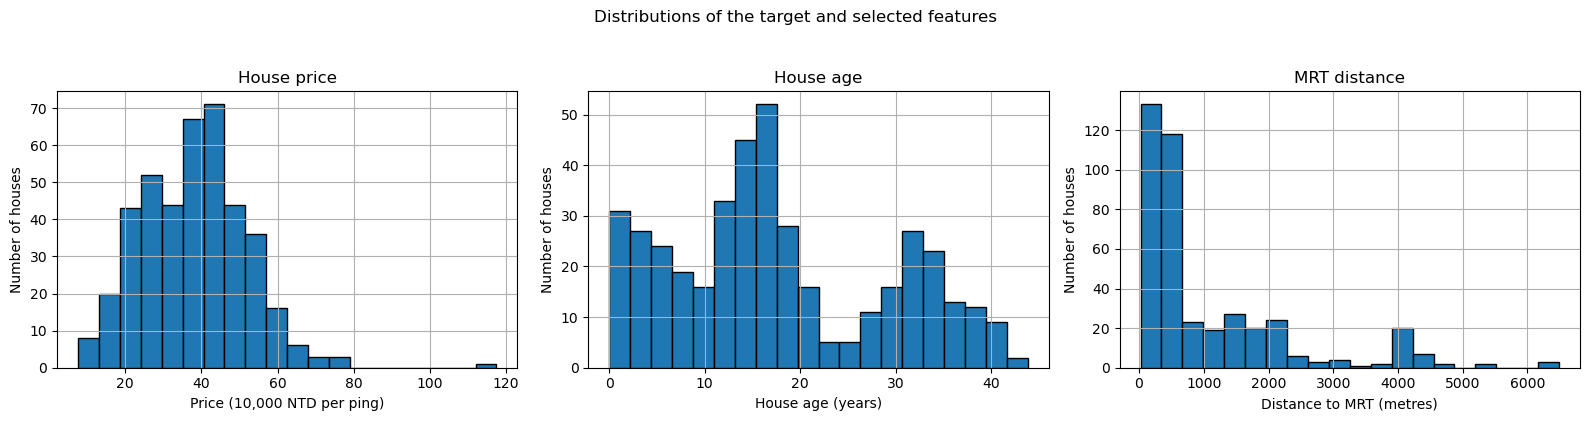

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(data["Y house price of unit area"], bins=20, edgecolor="black")
axes[0].set_xlabel("Price (10,000 NTD per ping)")
axes[0].set_ylabel("Number of houses")
axes[0].set_title("House price")

axes[1].hist(data["X2 house age"], bins=20, edgecolor="black")
axes[1].set_xlabel("House age (years)")
axes[1].set_ylabel("Number of houses")
axes[1].set_title("House age")

axes[2].hist(
    data["X3 distance to the nearest MRT station"],
    bins=20,
    edgecolor="black",
)
axes[2].set_xlabel("Distance to MRT (metres)")
axes[2].set_ylabel("Number of houses")
axes[2].set_title("MRT distance")

fig.suptitle("Distributions of the target and selected features", y=1.04)
plt.tight_layout()
plt.show()

### Initial observations

- All eight columns are numeric, and every column contains all 414 values.
- Most unit-area prices lie between approximately 20 and 60, with a peak around 35–45. The distribution is right-skewed and contains one unusually high value near
  118 which may influence on a squared-error model.
- House age forms several clusters rather than one smooth distribution/pattern.
- MRT distance is strongly right-skewed. Most houses are relatively close to a station, while a few are approximately 4–6.5 km away.
- The feature scales are very different: house age reaches about 44, whereas MRT distance reaches about 6,488. 

## Part (b) — One feature

Let $x_i$ be the age of house $i$, $y_i$ its true price, and $\hat y_i$ its predicted
price. The model is

$$
\hat y_i = w_0 + w_1x_i,
$$

where $w_0$ is the intercept and $w_1$ is the slope.

For $N$ houses, the mean squared error is

$$
L(w_0,w_1)
= \frac{1}{N}\sum_{i=1}^{N}(\hat y_i-y_i)^2
= \frac{1}{N}\sum_{i=1}^{N}(w_0+w_1x_i-y_i)^2.
$$

Using the chain rule,

$$
\frac{\partial L}{\partial w_0}
= \frac{1}{N}\sum_{i=1}^{N}
2(w_0+w_1x_i-y_i)
\frac{\partial(w_0+w_1x_i-y_i)}{\partial w_0}
= \frac{2}{N}\sum_{i=1}^{N}(w_0+w_1x_i-y_i),
$$

and

$$
\frac{\partial L}{\partial w_1}
= \frac{1}{N}\sum_{i=1}^{N}
2(w_0+w_1x_i-y_i)
\frac{\partial(w_0+w_1x_i-y_i)}{\partial w_1}
= \frac{2}{N}\sum_{i=1}^{N}x_i(w_0+w_1x_i-y_i).
$$

Gradient descent moves in the direction opposite the gradient:

$$
w_0 \leftarrow w_0-\eta\frac{\partial L}{\partial w_0},
\qquad
w_1 \leftarrow w_1-\eta\frac{\partial L}{\partial w_1},
$$

where $\eta$ is the learning rate.

### Prepare the feature and target arrays

In [178]:
x = data["X2 house age"].to_numpy()
y = data["Y house price of unit area"].to_numpy()

print("Shape of x:", x.shape)
print("Shape of y:", y.shape)
print("First five house ages:", x[:5])
print("First five prices:", y[:5])

Shape of x: (414,)
Shape of y: (414,)
First five house ages: [32.  19.5 13.3 13.3  5. ]
First five prices: [37.9 42.2 47.3 54.8 43.1]


### Gradient descent from scratch

I chose a learning rate of 0.001 because it produces a smooth, stable decrease in the loss. The model is run for 20,000 epochs so the loss curve has enough time to reach a clear plateau. Both the gradients are computed before either weight is updated, so the two updates use the same model state.

In [181]:
w0 = 0.0
w1 = 0.0
learning_rate = 0.001
epochs = 20_000
loss_history = []

for epoch in range(epochs):
    y_pred = w0 + w1 * x
    errors = y_pred - y

    loss = np.mean(errors**2)
    loss_history.append(loss)

    grad_w0 = 2 * np.mean(errors)
    grad_w1 = 2 * np.mean(errors * x)

    w0 = w0 - learning_rate * grad_w0
    w1 = w1 - learning_rate * grad_w1

# Recompute predictions and loss using the final updated weights.
y_pred_one = w0 + w1 * x
one_feature_loss = np.mean((y_pred_one - y)**2)

print(f"Learning rate: {learning_rate}")
print(f"Epochs: {epochs:,}")
print(f"Final w0: {w0:.6f}")
print(f"Final w1: {w1:.6f}")
print(f"Final MSE: {one_feature_loss:.6f}")

Learning rate: 0.001
Epochs: 20,000
Final w0: 42.434335
Final w1: -0.251474
Final MSE: 176.500474


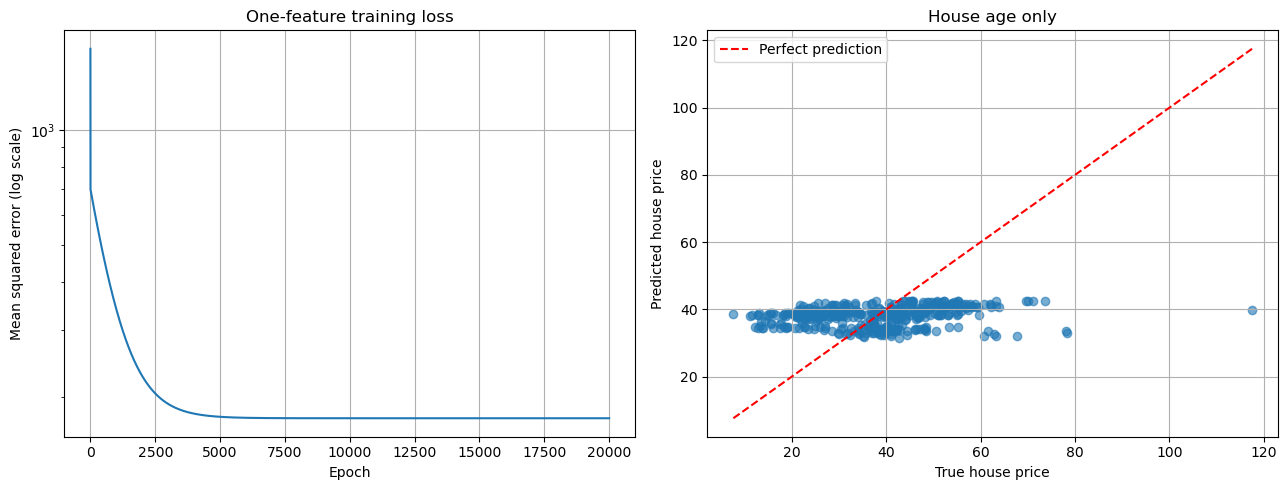

Initial loss: 1627.184396
Loss halfway: 176.504958
Final loss: 176.500474


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(loss_history)
axes[0].set_yscale("log")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean squared error (log scale)")
axes[0].set_title("One-feature training loss")

axes[1].scatter(y, y_pred_one, alpha=0.6)
plot_min = min(y.min(), y_pred_one.min())
plot_max = max(y.max(), y_pred_one.max())
axes[1].plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "r--",
    label="Perfect prediction",
)
axes[1].set_xlabel("True house price")
axes[1].set_ylabel("Predicted house price")
axes[1].set_title("House age only")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Initial loss: {loss_history[0]:.6f}")
print(f"Loss halfway: {loss_history[len(loss_history)//2]:.6f}")
print(f"Final loss: {loss_history[-1]:.6f}")

### Interpretation of the one-feature model

The loss decreases smoothly and becomes essentially flat, so the selected learning rate is stable and 20,000 epochs are sufficient. However, we can clealry see that house age alone is not a strong predictor of price. The predictions occupy a narrow range and do not follow the perfect-prediction line very well: inexpensive houses tend to be overpredicted and expensive houses tend to be underpredicted. Other property features are likely needed to explain most of the variation in price.

## Part (c) — More features

For each house, append a constant 1 to the feature vector (for the intercept):

$$
\mathbf{x}_i =
\begin{bmatrix}1 & x_{i1} & x_{i2}\end{bmatrix}^{T},
\qquad
\mathbf{w} =
\begin{bmatrix}w_0 & w_1 & w_2\end{bmatrix}^{T}.
$$

The prediction for one house is $\hat y_i=\mathbf{x}_i^T\mathbf w$. For the entire
dataset,

$$
\hat{\mathbf y}=X\mathbf w.
$$

Writing the residual vector as $\mathbf e=X\mathbf w-\mathbf y$, the mean squared
error is

$$
L(\mathbf w)=\frac{1}{N}\mathbf e^T\mathbf e
=\frac{1}{N}(X\mathbf w-\mathbf y)^T(X\mathbf w-\mathbf y).
$$

For weight $w_j$,

$$
\frac{\partial L}{\partial w_j}
=\frac{2}{N}\sum_{i=1}^{N}X_{ij}e_i.
$$

Stacking these derivatives gives the vector gradient

$$
\nabla_{\mathbf w}L
=\frac{2}{N}X^T(X\mathbf w-\mathbf y),
$$

and the update is

$$
\mathbf w\leftarrow\mathbf w-\eta\nabla_{\mathbf w}L.
$$

### Construct the raw feature matrix

Each row of $X$ represents one house. Its columns are the constant 1, house age, and
distance to the nearest MRT station.

In [9]:
feature_names = [
    "X2 house age",
    "X3 distance to the nearest MRT station",
]

X_features = data[feature_names].to_numpy()
X_raw = np.column_stack([np.ones(len(data)), X_features])

print("Shape of X:", X_raw.shape)
print("Shape of y:", y.shape)
print("First row of X:", X_raw[0])

Shape of X: (414, 3)
Shape of y: (414,)
First row of X: [ 1.      32.      84.87882]


### A reusable gradient-descent implementation

The function below works with any number of feature columns. I also implemented a finite divergence limit which deliberately stops unstable experiments before floating-point overflow occurs; it does not alter a normally converging run.

In [10]:
def gradient_descent(X, y, learning_rate, epochs, divergence_limit=None):
    weights = np.zeros(X.shape[1])
    loss_history = []
    stopped_early = False

    for epoch in range(epochs):
        y_pred = X @ weights
        errors = y_pred - y
        loss = np.mean(errors**2)
        loss_history.append(loss)

        if divergence_limit is not None and loss > divergence_limit:
            stopped_early = True
            break

        gradient = (2 / len(y)) * (X.T @ errors)
        weights = weights - learning_rate * gradient

    return weights, np.array(loss_history), stopped_early

### Experiment 1: raw features

The same learning rate used in part (b) is first applied to the unscaled features.
This isolates the effect of feature scale.

In [11]:
raw_weights, raw_loss_history, raw_stopped_early = gradient_descent(
    X=X_raw,
    y=y,
    learning_rate=0.001,
    epochs=20_000,
    divergence_limit=1e100,
)

print("Stopped early because the loss diverged:", raw_stopped_early)
print("Completed epochs:", len(raw_loss_history))
print(f"Initial loss: {raw_loss_history[0]:.6e}")
print(f"Last recorded loss: {raw_loss_history[-1]:.6e}")

Stopped early because the loss diverged: True
Completed epochs: 15
Initial loss: 1.627184e+03
Last recorded loss: 1.957571e+107


### Experiment 2: normalized features

Each feature is standardized using

$$
x_{\mathrm{normalized}}=\frac{x-\mu_x}{\sigma_x}.
$$

I added the intercept column after normalization and therefore it remains a column
of ones.

In [12]:
feature_means = X_features.mean(axis=0)
feature_stds = X_features.std(axis=0)

X_features_normalized = (X_features - feature_means) / feature_stds
X_normalized = np.column_stack([
    np.ones(len(data)),
    X_features_normalized,
])

print("Normalized feature means:", X_features_normalized.mean(axis=0))
print("Normalized feature standard deviations:", X_features_normalized.std(axis=0))

Normalized feature means: [-9.22504156e-17 -1.26576152e-16]
Normalized feature standard deviations: [1. 1.]


In [13]:
normalized_weights, normalized_loss_history, normalized_stopped_early = gradient_descent(
    X=X_normalized,
    y=y,
    learning_rate=0.001,
    epochs=20_000,
)

y_pred_multi = X_normalized @ normalized_weights
multi_feature_loss = np.mean((y_pred_multi - y)**2)

print("Stopped early:", normalized_stopped_early)
print("Normalized-feature weights:", normalized_weights)
print(f"Final normalized-feature MSE: {multi_feature_loss:.6f}")

Stopped early: False
Normalized-feature weights: [37.98019324 -2.62878615 -9.087074  ]
Final normalized-feature MSE: 93.979770


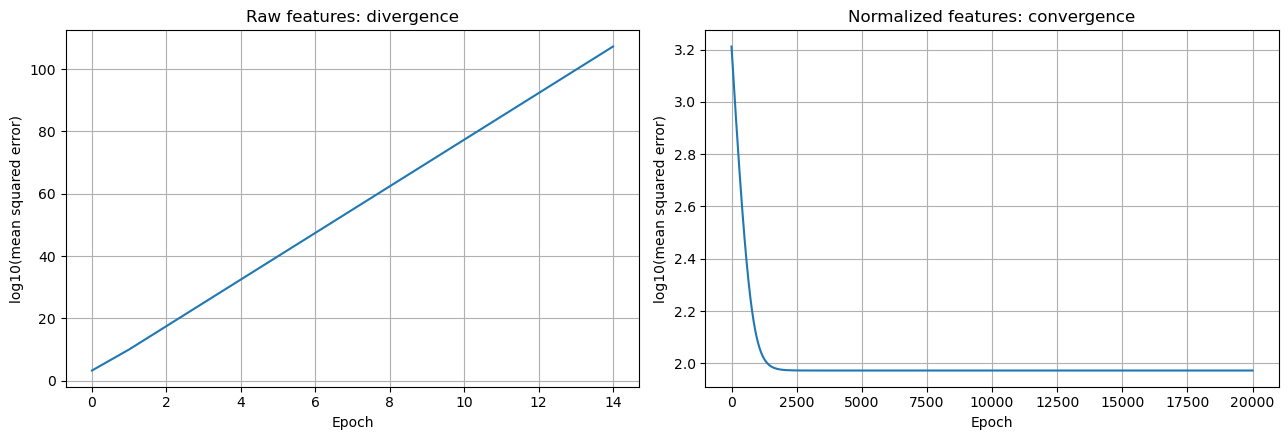

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(np.log10(raw_loss_history))
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("log10(mean squared error)")
axes[0].set_title("Raw features: divergence")

axes[1].plot(np.log10(normalized_loss_history))
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("log10(mean squared error)")
axes[1].set_title("Normalized features: convergence")

plt.tight_layout()
plt.show()

### Why normalization fixes the optimization

On the raw features, MRT distance reaches several thousand while house age reaches only about 44. The distance values therefore produce extremely large gradient terms. With a learning rate of 0.001, the updates repeatedly overshoot the minimum, and the loss grows rather than shrinks.

Normalization gives both features mean zero and standard deviation one, making their gradient contributions comparable in scale. With the same learning rate and epoch limit, the normalized model converges smoothly to an MSE of approximately 93.98, compared with approximately 176.50 for the age-only model.

For the normalized model, the weights are approximately

$$
\mathbf w=
\begin{bmatrix}37.98 & -2.63 & -9.09\end{bmatrix}^{T}.
$$

The intercept is the predicted price when both raw features equal their means. Holding the other feature fixed, a one-standard-deviation increase in house age changes the predicted price by about $-2.63$, while a one-standard-deviation increase in MRT distance changes it by about $-9.09$.

## Part (d) — What did we learn

### Numerical and visual comparison

In [15]:
improvement_percent = 100 * (
    one_feature_loss - multi_feature_loss
) / one_feature_loss

comparison = pd.DataFrame({
    "Model": [
        "House age only",
        "House age + MRT distance",
    ],
    "Final MSE": [one_feature_loss, multi_feature_loss],
})

print(f"MSE reduction after adding MRT distance: {improvement_percent:.1f}%")
comparison

MSE reduction after adding MRT distance: 46.8%


,Model,Final MSE
0,House age only,176.500474
1,House age + MRT distance,93.979770


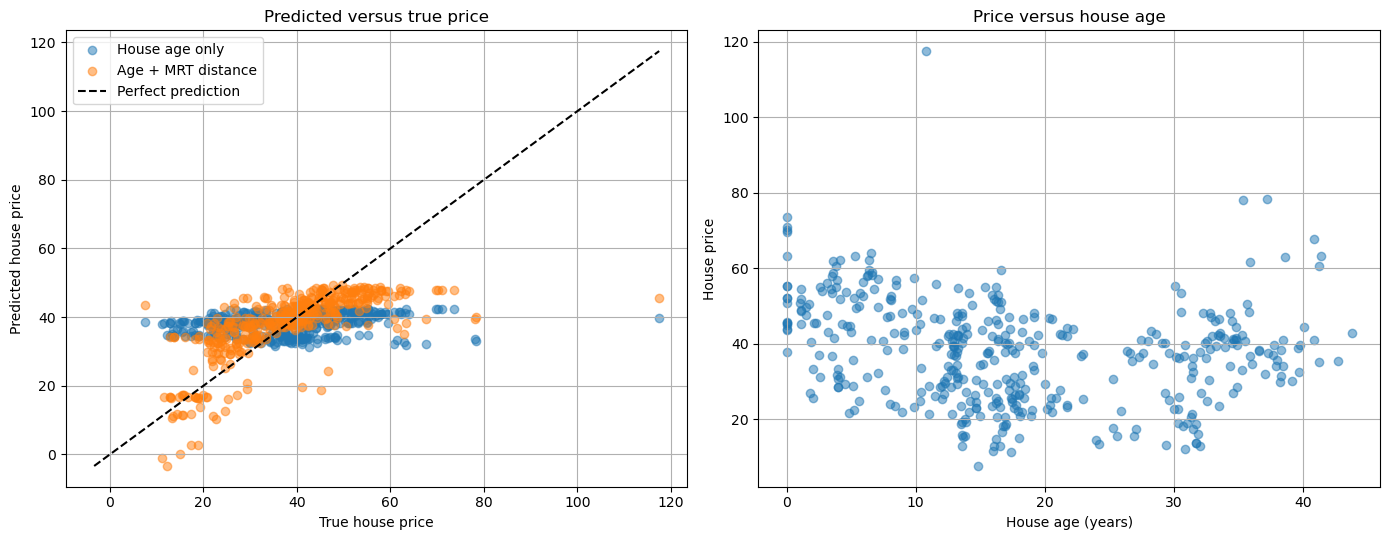

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(y, y_pred_one, alpha=0.5, label="House age only")
axes[0].scatter(y, y_pred_multi, alpha=0.5, label="Age + MRT distance")
plot_min = min(y.min(), y_pred_one.min(), y_pred_multi.min())
plot_max = max(y.max(), y_pred_one.max(), y_pred_multi.max())
axes[0].plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    "k--",
    label="Perfect prediction",
)
axes[0].set_xlabel("True house price")
axes[0].set_ylabel("Predicted house price")
axes[0].set_title("Predicted versus true price")
axes[0].legend()

axes[1].scatter(data["X2 house age"], y, alpha=0.5, label="House age")
axes[1].set_xlabel("House age (years)")
axes[1].set_ylabel("House price")
axes[1].set_title("Price versus house age")

plt.tight_layout()
plt.show()

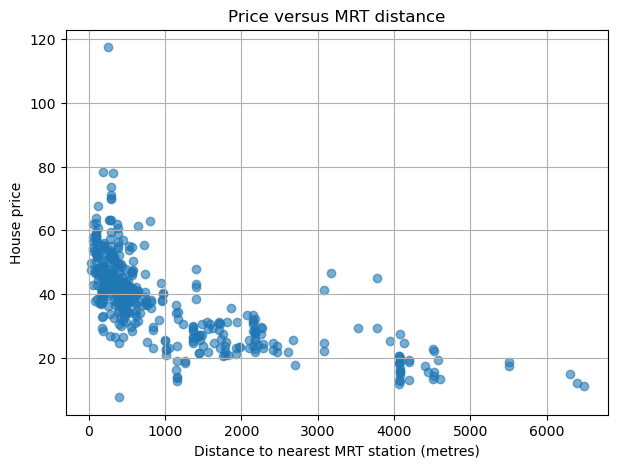

In [17]:
plt.figure(figsize=(7, 5))
plt.scatter(
    data["X3 distance to the nearest MRT station"],
    y,
    alpha=0.6,
)
plt.xlabel("Distance to nearest MRT station (metres)")
plt.ylabel("House price")
plt.title("Price versus MRT distance")
plt.show()

### Discussion

The one-feature model reached an MSE of approximately 176.50. Adding MRT distance reduced the MSE to approximately 93.98, an improvement of about 46.8%. The multi-feature predictions generally lie closer to the perfect-prediction line and cover a wider range, although the model still rather off.

House age carries some information, but its relationship with price is weak and noisy. MRT distance carries substantially more information: price generally falls as distance from a station increases. This is consistent with both the scatter plot and the larger magnitude of the normalized MRT coefficient.

Feature scale caused gradient descent to diverge on the raw two-feature data. Normalization fixed that problem. The learning rate of 0.001 was stable after normalization, and the loss reached a plateau well before 20,000 epochs, so too few epochs was not a limitation. The unusual target value near 118 has a large squared error, and both models are limited by the assumption of a linear relationship.

I would investigate the unusual observations, add potentially useful predictors such as geographic location and the number of convenience stores, and test whether nonlinear terms improve the fit. I would also evaluate performance on held-out data rather than using the same data for both fitting and evaluation. This would provide evidence about how well the model generalizes to unseen houses (which after this week's class I now understand is an actual procedure we need to take).

## Bonus

For a linear model, setting the gradient equal to zero gives

$$
X^T(X\mathbf w-\mathbf y)=0,
$$

and therefore

$$
\mathbf w_{\mathrm{closed}}=(X^TX)^{-1}X^T\mathbf y.
$$

The code uses `numpy.linalg.solve()` to solve $(X^TX)\mathbf w=X^T\mathbf y$. This is mathematically equivalent to the normal equation but avoids explicitly computing a matrix inverse.

In [18]:
XTX = X_normalized.T @ X_normalized
XTy = X_normalized.T @ y

closed_form_weights = np.linalg.solve(XTX, XTy)
closed_form_predictions = X_normalized @ closed_form_weights
closed_form_loss = np.mean((closed_form_predictions - y)**2)

weight_difference = normalized_weights - closed_form_weights
largest_difference = np.max(np.abs(weight_difference))
loss_difference = multi_feature_loss - closed_form_loss

print("Gradient-descent weights:", normalized_weights)
print("Closed-form weights:", closed_form_weights)
print("Weight differences:", weight_difference)
print(f"Largest absolute weight difference: {largest_difference:.3e}")
print(f"Gradient-descent loss: {multi_feature_loss:.12f}")
print(f"Closed-form loss: {closed_form_loss:.12f}")
print(f"Loss difference: {loss_difference:.3e}")

Gradient-descent weights: [37.98019324 -2.62878615 -9.087074  ]
Closed-form weights: [37.98019324 -2.62878615 -9.087074  ]
Weight differences: [-1.77635684e-12 -1.23012711e-13  4.42312853e-13]
Largest absolute weight difference: 1.776e-12
Gradient-descent loss: 93.979769639381
Closed-form loss: 93.979769639381
Loss difference: 1.421e-14


### How many epochs are needed?

I take "close enough" to mean that every gradient-descent weight is within 0.001 of its closed-form value. Since the input features are normalized, a weight difference of this size has a negligible effect on a typical prediction compared with the model's overall prediction error.

In [19]:
tolerance = 1e-3
weights = np.zeros(X_normalized.shape[1])
epochs_needed = None

for epoch in range(20_000):
    y_pred = X_normalized @ weights
    errors = y_pred - y
    gradient = (2 / len(y)) * (X_normalized.T @ errors)
    weights = weights - 0.001 * gradient

    max_weight_difference = np.max(
        np.abs(weights - closed_form_weights)
    )
    if max_weight_difference < tolerance:
        epochs_needed = epoch + 1
        break

print("Tolerance:", tolerance)
print("Epochs needed:", epochs_needed)
print("Weights at that epoch:", weights)
print("Largest weight difference:", max_weight_difference)

Tolerance: 0.001
Epochs needed: 5268
Weights at that epoch: [37.97919497 -2.62877991 -9.08684529]
Largest weight difference: 0.0009982714987231134


### Conclusion

The closed-form solution gives weights of approximately $[37.9802,-2.6288,-9.0871]$ and an MSE of 93.9798. After 20,000 epochs, gradient
descent differs from the closed-form weights by only about $1.78\times10^{-12}$, and the loss difference is about $1.42\times10^{-14}$. These negligible discrepancies are likely due to floating-point rounding.

Using the stated tolerance of 0.001, gradient descent first becomes sufficiently close to the closed-form solution after **5,268 epochs**. The agreement confirms that the implemented gradients and updates converge to the correct least-squares solution.